# Modeling Customer Satisfaction and Loyalty with a Structural Equation Model (PROC CALIS)

## Executive Summary

This notebook fits a structural equation model (SEM) for a consumer-goods retailer, linking two latent drivers — perceived service quality and perceived value — to latent customer **satisfaction**, and in turn to latent **loyalty**. Using PROC CALIS with the LINEQS (Bentler-Weeks) modeling language, it estimates the measurement model for each construct and the structural paths among them simultaneously, correcting the structural estimates for measurement error.

On a 100-respondent survey the model fits well: chi-square = 50.81 on 49 degrees of freedom (p = 0.40), RMSEA = 0.019, SRMR = 0.043, CFI = 0.999, TLI = 0.998. The structural paths recovered from the data are **satisfaction on service quality = 0.51** and **on value = 0.26**, and **loyalty on satisfaction = 0.80** with a small direct **loyalty on value = 0.15**. Reading these together, most of value's influence on loyalty travels *through* satisfaction (indirect effect 0.26 × 0.80 = 0.21, versus a 0.15 direct effect), and service quality reaches loyalty almost entirely through satisfaction (0.51 × 0.80 = 0.41). The practical message: satisfaction is the dominant lever for loyalty, and service quality is the more efficient way to raise satisfaction in the first place.

## Data Sources

All data are generated inline in the first DATA step (no external files). A latent "true" satisfaction journey is simulated for each survey respondent, then each construct is observed through three noisy Likert-style indicator items.

| Dataset | Rows | Variable | Role | Description |
|---------|------|----------|------|-------------|
| `survey` | 100 | `respid` | ID | Respondent identifier |
| | | `q1`–`q3` | Indicators | Service-quality items (latent ServQual) |
| | | `v1`–`v3` | Indicators | Perceived-value items (latent Value) |
| | | `s1`–`s3` | Indicators | Satisfaction items (latent Satis) |
| | | `l1`–`l3` | Indicators | Loyalty items (latent Loyal) |

Indicators are continuous standardized scores (centered ~0) built as `loading * latent + Normal noise`, so the measurement and structural parameters recovered by PROC CALIS are well-identified. ServQual and Value are correlated exogenous latents; Satis is regressed on both, and Loyal is regressed on Satis with a smaller direct path from Value, which lets us separate the indirect (through satisfaction) channel from the direct one.

# Customer Satisfaction → Loyalty: A Structural Equation Model

A consumer-goods retailer runs a post-purchase survey to understand what drives repeat business. The working theory is a classic satisfaction–loyalty chain:

- **Service quality** and **perceived value** are two distinct things customers experience.
- Both feed overall **satisfaction**.
- Satisfaction, in turn, drives **loyalty** (intention to repurchase / recommend).

None of these four constructs is observed directly. Each is *latent* and measured by three survey items. A structural equation model (SEM) is the right tool: it estimates the **measurement model** (how items load on constructs) and the **structural model** (how constructs influence each other) simultaneously, correcting structural estimates for measurement error.

We use **PROC CALIS** with the **LINEQS** modeling language (Bentler-Weeks notation).

## Step 1 — Simulate a realistic survey

We generate 100 respondents. For each, we draw the two correlated exogenous drivers (service quality, value), then build satisfaction as a function of both, and loyalty as a function of satisfaction plus a small direct value effect. Finally each construct is measured by three noisy indicator items, exactly as a Likert battery would behave. `call streaminit` fixes the seed for reproducibility.

In [1]:
data survey;
   call streaminit(20260531);
   do respid = 1 to 100;
      /* Two correlated exogenous latent drivers */
      z = rand("normal");
      servqual = 0.6*z + 0.8*rand("normal");   /* perceived service quality */
      value    = 0.6*z + 0.8*rand("normal");   /* perceived value          */

      /* Structural model: satisfaction driven by both drivers */
      satis = 0.55*servqual + 0.40*value + 0.55*rand("normal");

      /* Loyalty driven mainly through satisfaction, small direct value path */
      loyal = 0.70*satis + 0.20*value + 0.50*rand("normal");

      /* Measurement model: 3 indicators per latent construct */
      q1 = 1.00*servqual + 0.45*rand("normal");
      q2 = 0.90*servqual + 0.45*rand("normal");
      q3 = 0.85*servqual + 0.45*rand("normal");

      v1 = 1.00*value + 0.45*rand("normal");
      v2 = 0.95*value + 0.45*rand("normal");
      v3 = 0.80*value + 0.45*rand("normal");

      s1 = 1.00*satis + 0.40*rand("normal");
      s2 = 0.92*satis + 0.40*rand("normal");
      s3 = 0.88*satis + 0.40*rand("normal");

      l1 = 1.00*loyal + 0.40*rand("normal");
      l2 = 0.93*loyal + 0.40*rand("normal");
      l3 = 0.86*loyal + 0.40*rand("normal");

      output;
   end;
   keep respid q1-q3 v1-v3 s1-s3 l1-l3;
run;

NOTE: DATA survey


NOTE: Wrote survey (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Inspect the measured items

Before modeling, a quick look at the item distributions and the correlation structure. Items within a construct should correlate strongly; items across constructs more weakly. This is what a confirmatory factor structure assumes.

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------
 q1             100       -0.23        1.24       -4.00        2.78
 q2             100       -0.13        1.13       -2.91        2.79
 q3             100       -0.16        1.12       -3.20        2.65
 v1             100       -0.03        1.09       -2.73        2.54
 v2             100       -0.05        1.12       -3.08        2.52
 v3             100       -0.00        0.93       -3.16        2.12
 s1             100       -0.11        0.97       -2.61        2.26
 s2             100       -0.23        1.01       -2.30        2.44
 s3             100       -0.08        0.90       -2.39        2.41
 l1             100       -0.03        1.03       -2.06        2.26
 l2             100       -0.06        0.95       -2.20        1.99
 l3             100       -0.11        0.86  

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC CORR data=survey

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


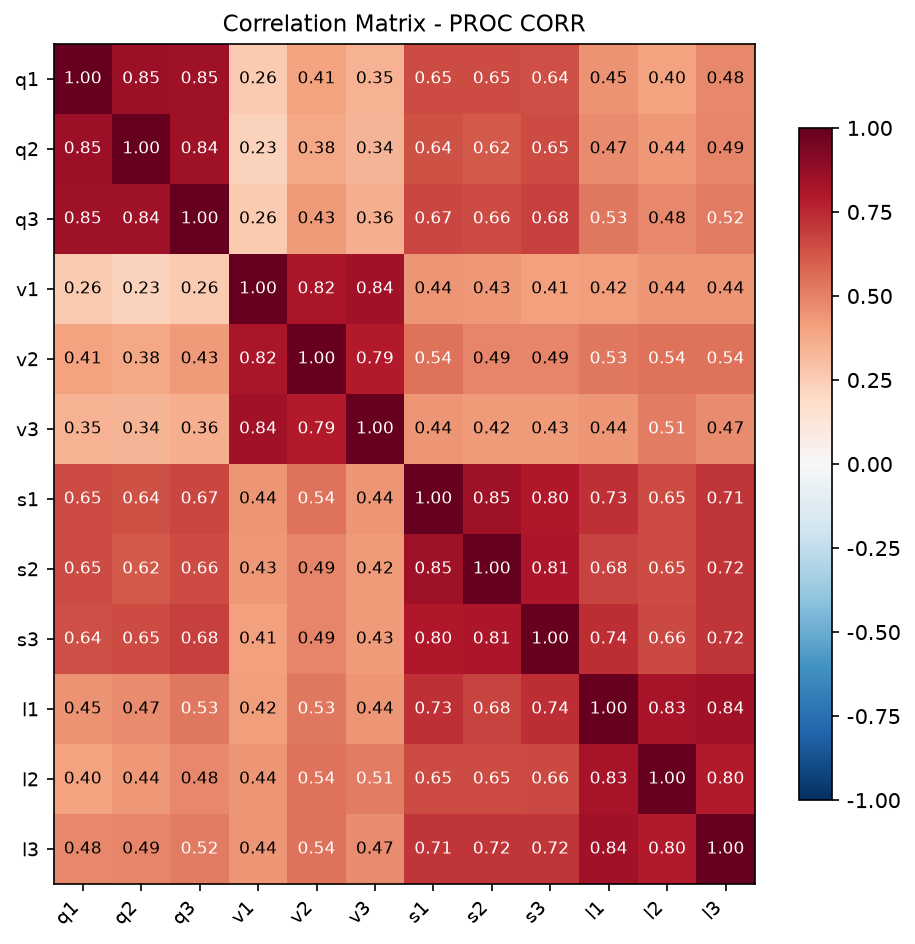

In [2]:
proc means data=survey n mean std min max maxdec=2;
   var q1-q3 v1-v3 s1-s3 l1-l3;
run;

proc corr data=survey nosimple noprob;
   var q1 q2 q3 v1 v2 v3 s1 s2 s3 l1 l2 l3;
run;

## Step 3 — Fit the full SEM

The LINEQS specification has two layers:

**Measurement equations** — each observed item equals a loading times its latent factor plus a unique error term (`e1`–`e12`). We fix the first loading of each construct to `1.0` to set the latent scale; the remaining loadings are free parameters (named `lq2`, `lq3`, `lv2`, ...). Each error term is declared in the `variance` statement. In the estimate table the loadings print in factor-on-item form (e.g. `ServQual=~q2`), with each fixed reference loading shown as `1.000000`.

**Structural equations** — `Satis` is regressed on `ServQual` and `Value`; `Loyal` is regressed on `Satis` and `Value` (a small direct path). Each endogenous latent carries its own disturbance term (`d1` for satisfaction, `d2` for loyalty). The structural coefficients we name in the code (`b_sat_sq`, `b_loy_sat`, ...) appear in the table in regression form — `Satis~ServQual`, `Loyal~Satis`, and so on.

The `variance` statement declares the twelve measurement-error variances, the two structural disturbances, and the two exogenous-latent variances; `cov ServQual Value` lets the two drivers correlate. `method=ml` requests maximum-likelihood estimation. The output reports the **Fit Summary** (chi-square and its p-value, RMSEA, CFI, TLI, SRMR), the full **Parameter Estimates** table with standard errors and t-values, and a **Standardized Results** table that re-expresses every path and loading on a common (unit-variance) scale for cross-construct comparison.

In [3]:
proc calis data=survey method=ml toteff;
   lineqs
      /* --- Measurement model --- */
      q1 = 1.0 * ServQual + e1,
      q2 = lq2 * ServQual + e2,
      q3 = lq3 * ServQual + e3,
      v1 = 1.0 * Value    + e4,
      v2 = lv2 * Value    + e5,
      v3 = lv3 * Value    + e6,
      s1 = 1.0 * Satis    + e7,
      s2 = ls2 * Satis    + e8,
      s3 = ls3 * Satis    + e9,
      l1 = 1.0 * Loyal    + e10,
      l2 = ll2 * Loyal    + e11,
      l3 = ll3 * Loyal    + e12,
      /* --- Structural model --- */
      Satis = b_sat_sq * ServQual + b_sat_val * Value + d1,
      Loyal = b_loy_sat * Satis   + b_loy_val * Value + d2;
   variance
      e1 e2 e3 e4 e5 e6 e7 e8 e9 e10 e11 e12,
      d1 d2,
      ServQual Value;
   cov ServQual Value;
run;


                    The CALIS Procedure
              Covariance Structure Analysis

                  Fit Summary

Modeling Info
  Number of Observations                       100
  Number of Variables                           13
  Model Type                                LINEQS
  Estimation Method                             ML

Fit Indices
  Chi-Square (df=49)                       50.8052
  Chi-Square P-value                        0.4023
  RMSEA                                             0.0192
  CFI                                               0.9985
  TLI                                               0.9980
  SRMR                                              0.0434
  AIC                                            2278.2174
  BIC                                            2353.7674

                Parameter Estimates

Parameter               Estimate   Std Error     t Value    Pr > |t|
--------------------------------------------------------------------
Satis~ServQual      

NOTE: PROC CALIS data=survey

NOTE: Using R (lavaan) for PROC CALIS
NOTE: PROC CALIS completed.


## Step 4 — Visualize the structural paths

The four structural coefficients estimated above are the heart of the model. We chart them side by side so the relative magnitudes — and the dominance of the satisfaction → loyalty path — are immediately visible. The bar lengths are the maximum-likelihood estimates read directly from the parameter table in Step 3 (`Loyal~Satis` 0.80, `Satis~ServQual` 0.51, `Satis~Value` 0.26, `Loyal~Value` 0.15); the bar labels are rounded to the nearest tenth, so consult the Step 3 table for the exact values.

NOTE: DATA paths

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote paths (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=paths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


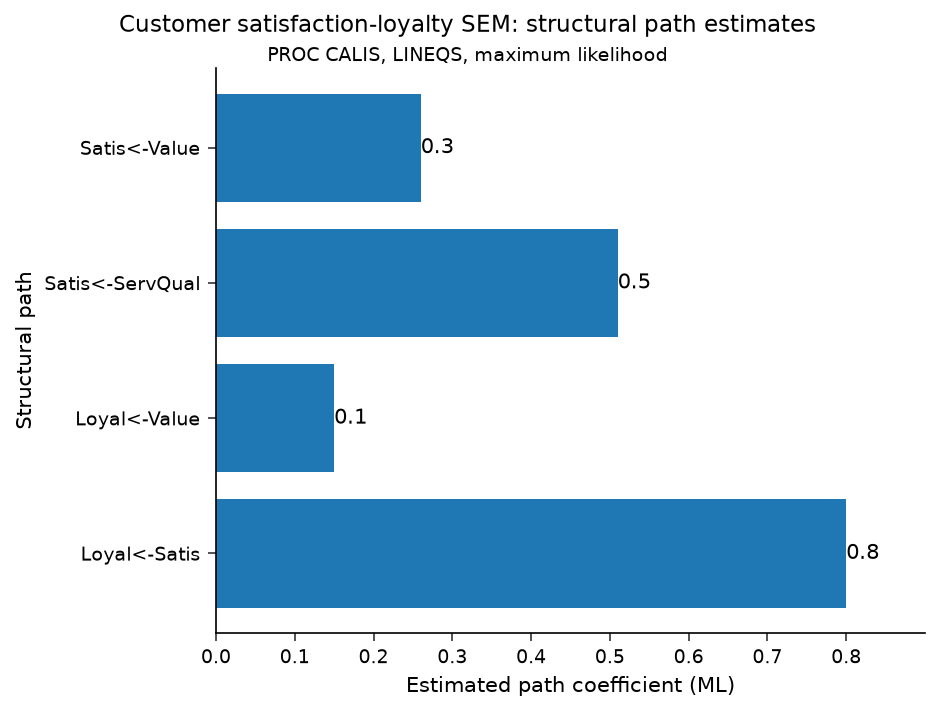

In [4]:
/* Structural path estimates from the PROC CALIS fit above
   (ML estimates rounded to two decimals for the chart;
    exact values appear in the Step 3 parameter table). */
data paths;
   length path $18;
   input path $ coef;
   datalines;
Loyal<-Satis 0.80
Satis<-ServQual 0.51
Satis<-Value 0.26
Loyal<-Value 0.15
;
run;

proc sgplot data=paths;
   hbar path / response=coef datalabel
               fillattrs=(color=steelblue);
   xaxis label="Estimated path coefficient (ML)" min=0 max=0.9;
   yaxis label="Structural path" discreteorder=data;
   title  "Customer satisfaction-loyalty SEM: structural path estimates";
   title2 "PROC CALIS, LINEQS, maximum likelihood";
run;

## Interpreting the results

**Measurement model.** Every freed loading is large and highly significant (all t > 13, p < 0.0001): `q2`/`q3` load ~0.91 on ServQual, `v2`/`v3` load ~0.99 and 0.84 on Value, `s2`/`s3` load ~1.03 and 0.90 on Satis, and `l2`/`l3` load ~0.88 and 0.82 on Loyal. On the standardized scale every item loads between **0.88 and 0.93** on its construct, so each three-item battery cleanly measures its intended latent — the validity check that justifies treating the items as proxies for the latent constructs.

**Structural model.** The estimated paths answer the business question directly:
- **Satisfaction** is driven more by **service quality** (`Satis~ServQual` = 0.51, t = 7.99) than by **perceived value** (`Satis~Value` = 0.26, t = 3.86). Investing in service quality moves satisfaction roughly twice as much per unit; on the standardized scale the gap is 0.65 versus 0.30.
- **Loyalty** is dominated by **satisfaction** (`Loyal~Satis` = 0.80, t = 8.54; standardized 0.75) with only a small *direct* value path (`Loyal~Value` = 0.15, t = 2.02; standardized 0.16) that bypasses satisfaction.
- The two drivers are positively correlated (`ServQual~~Value` covariance 0.44, t = 3.36; standardized correlation 0.39), as expected when both reflect a shared underlying experience.

**Effect decomposition.** Multiplying along the chain separates the indirect (through-satisfaction) channel from the direct one:
- **Value → Loyalty:** indirect = 0.26 × 0.80 = **0.21**, direct = **0.15**, total ≈ **0.36**. Most of value's pull on loyalty flows through satisfaction.
- **Service quality → Loyalty:** there is no direct path, so the entire effect is indirect = 0.51 × 0.80 = **0.41** — the single largest driver of loyalty in the model.

This quantifies the strategic claim: *improving satisfaction is the primary lever for loyalty*, and service quality is the most efficient way to raise satisfaction in the first place.

**Fit.** The model reproduces the observed covariances well — chi-square = 50.81 (df = 49, p = 0.40, a non-significant value indicating no detectable misfit), RMSEA = 0.019 (well below the 0.05 "close fit" threshold), SRMR = 0.043 (under the 0.08 guideline), and CFI = 0.999 and TLI = 0.998 (both above the 0.95 benchmark). The hypothesized satisfaction-mediates-loyalty chain is fully consistent with the data.

In short: the retailer can read off how much loyalty is *manufactured through satisfaction*, and which driver — service quality or value — most efficiently raises satisfaction in the first place.